In [1]:
import pathlib

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chisquare
from statsmodels.stats.proportion import proportion_confint

%matplotlib inline

In [2]:
repository_path = pathlib.Path.cwd().parents[2]
simulations_path = repository_path / "data" / "simulations"
bgg_path = repository_path / "data" / "bgg"

In [3]:
simulation_games_data = pd.read_csv(simulations_path / "games.csv")

simulation_games_data.head()

,game_id,seed,player_count,outcome,rounds_played,boat_parts_built,boat_parts_required,volcano_cards_remaining,mission_failures_any_extra
0,296325ecc0d5ffe2,20260428,6,win,20,3,3,2,1
1,259a5d07d71f3473,20260429,6,win,20,3,3,1,0
2,74570438e9a72e0c,20260430,6,loss,13,2,3,0,0
3,6559fe61497155ac,20260431,6,win,15,3,3,4,0
4,5723fa7ec997a08b,20260432,6,loss,16,2,3,0,0


# Hypothesis 1 - Player-count balance

**Question.** Does the number of players change the team's win probability?

- **$H_0$:** $P(\text{win} \mid 6\ \text{players}) = P(\text{win} \mid 7\ \text{players}) = P(\text{win} \mid 8\ \text{players})$
- **$H_1$:** at least one of the three win probabilities differs from the others

**Test.** Chi-square goodness-of-fit on the observed win counts across the three player-count groups, against equal expected counts (the simpler one-way form is valid here because the three groups have equal sample size of 4,000 games each). Per-group 95% Wilson confidence intervals on the win rate as supplementary effect sizes. Significance level $\alpha = 0.05$. The decision is reported here against the uncorrected threshold; the Holm-Bonferroni correction across all seven hypotheses is applied in the summary table in the main notebook.

**Sanity check.** The sampling plan specifies 4,000 games per player count (12,000 total).

In [4]:
games_per_count = simulation_games_data.groupby("player_count").size()
games_per_count

player_count
6    4000
7    4000
8    4000
dtype: int64

**Contingency table** of outcome by player count, followed by the per-group win rate.

In [5]:
game_outcomes_per_player_count = simulation_games_data.pivot_table(
    index = "player_count",
    columns = "outcome",
    aggfunc = "size",
    fill_value = 0,
)
game_outcomes_per_player_count

outcome,loss,win
player_count,,
6,2317,1683
7,2084,1916
8,1912,2088


In [6]:
win_rate_per_player_count = game_outcomes_per_player_count["win"] / games_per_count
win_rate_per_player_count

player_count
6    0.42075
7    0.47900
8    0.52200
dtype: float64

**Plot** the per-group win rates for orientation before running the test.

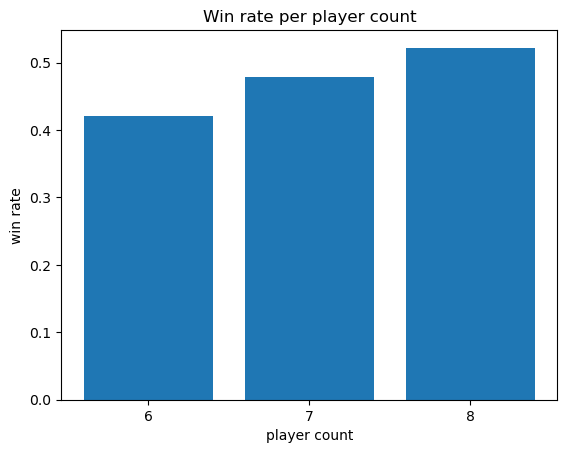

In [7]:
plt.bar(win_rate_per_player_count.index, win_rate_per_player_count.values)

plt.xlabel("player count")
plt.ylabel("win rate")
plt.xticks(win_rate_per_player_count.index)
plt.title("Win rate per player count")

plt.show()

**Chi-square test** against equal expected win counts across the three player-count groups.

In [8]:
chisquare_result = chisquare(
    f_obs = game_outcomes_per_player_count["win"],
    f_exp = [game_outcomes_per_player_count["win"].mean()] * len(game_outcomes_per_player_count),
)

print(f"chi-square statistic: {chisquare_result.statistic:.4f}")
print(f"p-value: {chisquare_result.pvalue:.2e}")

chi-square statistic: 43.5903
p-value: 3.42e-10


**95% Wilson confidence intervals** per player count. Non-overlapping intervals imply pairwise differences significant at the 5% level without needing a separate pairwise test.

In [9]:
for player_count in win_rate_per_player_count.index:
    wins = game_outcomes_per_player_count.loc[player_count, "win"]
    total_games = games_per_count.loc[player_count]
    ci_lower, ci_upper = proportion_confint(wins, total_games, method = "wilson")
    win_rate = win_rate_per_player_count.loc[player_count]

    print(f"{player_count} players: win rate = {win_rate:.4f}, 95% CI = [{ci_lower:.4f}, {ci_upper:.4f}]")

6 players: win rate = 0.4208, 95% CI = [0.4055, 0.4361]
7 players: win rate = 0.4790, 95% CI = [0.4635, 0.4945]
8 players: win rate = 0.5220, 95% CI = [0.5065, 0.5375]


## Decision

The chi-square test gives $\chi^2 = 43.59$ with $p = 3.4 \times 10^{-10}$, well below $\alpha = 0.05$, so we **reject $H_0$** in favour of $H_1$: win probability is not the same across the three player counts. The three Wilson 95% confidence intervals are disjoint (`[0.406, 0.436]`, `[0.464, 0.494]`, `[0.506, 0.538]`), which confirms each pairwise difference at the 5% level independently of the global test.

The direction is consistent: win rate rises monotonically with player count, from 42.1% at 6 players to 47.9% at 7 and 52.2% at 8. That runs counter to the naive design expectation that larger groups would struggle more with coordination - in this simulation, more players means more available hands to absorb the per-participant resource costs of complications and volcano cards, which more than offsets the additional boat-part requirement. **Volcano Rush is therefore not balanced across player counts under the current rules**, and the 6-player configuration in particular sits below the 50-65% design-target band. This should be flagged as a balance concern in the discussion section of the main notebook.